# Barcelona Noise Prediction: Land Use Feature Engineering
This notebook processes the official Barcelona land use shapefile and calculates the percentage of commercial, residential, industrial, green, and recreational areas within 50m and 100m buffers of our street network.

In [ ]:
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import pandas as pd

print("Loading spatial data...")
# Load data (ensure your file paths match your VS Code workspace)
noise_streets = gpd.read_file("../../layers/BCN_noise_streets.gpkg")
noise_streets['fid'] = noise_streets.index # Assign explicitly a numeric FID
print(noise_streets.crs)  #CRS = Coordinate Reference System
print(noise_streets.shape)
print(noise_streets.columns.tolist())
print("Number of street segments:", len(noise_streets))

landuse = gpd.read_file("../../layers/bcn_usossl_etrs89_shp.gpkg")
print(landuse.crs)  #CRS = Coordinate Reference System
print(landuse.shape)
print(landuse.columns.tolist())
print("Number of land use polygons:", len(landuse))

# Quick sanity check to see the loaded data
display(landuse.head(2))

Loading spatial data...
EPSG:25831
(15115, 30)
['TRAM', 'TOTAL_D', 'TOTAL_E', 'TOTAL_N', 'TOTAL_DEN', 'TRANSIT_D', 'TRANSIT_E', 'TRANSIT_N', 'TRANSIT_DEN', 'GI_TR_D', 'GI_TR_E', 'GI_TR_N', 'GI_TR_DEN', 'FFCC_D', 'FFCC_E', 'FFCC_N', 'FFCC_DEN', 'INDUST_D', 'INDUST_E', 'INDUST_N', 'INDUST_DEN', 'VIANANTS_D', 'VIANANTS_E', 'OCI_N', 'PATIS_D', 'PATIS_E', 'geometry_type', 'start', 'end', 'geometry']
Number of street segments: 15115
EPSG:25831
(14320, 14)
['FAMILIA', 'CLAU', 'District', 'NDistric', 'CBarri', 'NBarri', 'C_AEB', 'CSecCens', 'Area', 'Perimetre', 'Coord_X', 'Coord_Y', 'Descripcio', 'geometry']
Number of land use polygons: 14320


,FAMILIA,CLAU,District,NDistric,CBarri,NBarri,C_AEB,CSecCens,Area,Perimetre,Coord_X,Coord_Y,Descripcio,geometry
0,22@,13hs,10,Sant Martí,66,el Parc i la Llacuna del Poblenou,208,042,735.029735,128.008296,432836.027297,4.583821e+06,13hs - 22@,"MULTIPOLYGON (((432764.589 4583628.639, 432747..."
1,22@,22@,10,Sant Martí,66,el Parc i la Llacuna del Poblenou,208,043,5749.281523,536.159605,432603.509491,4.583503e+06,22@ - 22@,"MULTIPOLYGON (((432566.688 4583298.456, 432562..."


## Categorize Land Use and Align CRS
We map the Catalan zoning categories to our 5 machine-learning buckets. Then, we force both datasets into EPSG:25831 (ETRS89 / UTM zone 31N) so our buffer math is perfectly calculated in meters.

In [3]:
zoning_to_ml_buckets = {
    '22@': 'commercial',
    'Casc Antic': 'residential',
    "Conservació de l'Estructura Urbana i Edificatòria": 'residential',
    'Densificació Urbana': 'residential',
    'Edificació aïllada subzones plurifamiliars': 'residential',
    'Edificació aïllada subzones unifamiliars': 'residential',
    'Habitatge dotacional i de protecció': 'residential',
    'Ordenació Volumètrica Específica': 'residential',
    'Remodelació Física': 'residential',
    'Renovació Urbana: Rehabilitació': 'residential',
    'Industrial': 'industrial',
    'Sistema de serveis tècnics': 'industrial',
    'Sistema ferroviari': 'industrial',
    'Sistema relatiu al port': 'industrial',
    'Protecció de Sistemes Generals i Vials': 'industrial',
    'Parc Forestal': 'green',
    'Parcs i Jardins Urbans': 'green',
    'Verd privat': 'green',
    "Transformació de l'ús existent (PARC)": 'green',
    'Equipaments Comunitaris i Dotacions': 'recreational',
    "Transformació de l'ús existent (EQUIPAMENT)": 'recreational' 
}

# Apply mapping
landuse['ml_category'] = landuse['FAMILIA'].map(zoning_to_ml_buckets).fillna('other')



## Categorization Analysis
Let's visualize the distribution of land use parcels before and after our ML bucketing process.

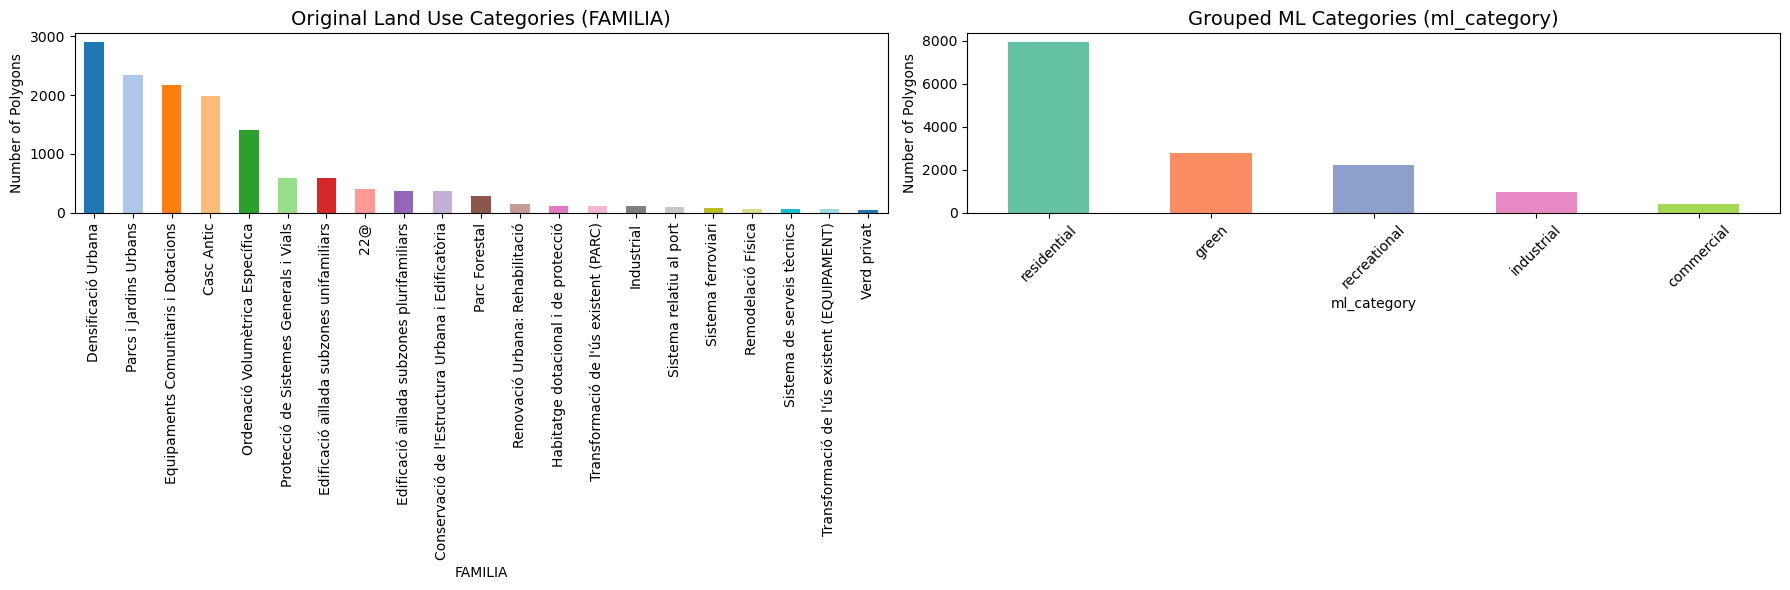

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

fam_counts = landuse['FAMILIA'].value_counts()
ml_counts = landuse['ml_category'].value_counts()

# Plot Before Grouping
fam_counts.plot(kind='bar', ax=axes[0], color=plt.cm.tab20.colors[:len(fam_counts)])
axes[0].set_title("Original Land Use Categories (FAMILIA)", fontsize=14)
axes[0].set_ylabel("Number of Polygons")
axes[0].tick_params(axis='x', rotation=90)

# Plot After Grouping 
ml_counts.plot(kind='bar', ax=axes[1], color=plt.cm.Set2.colors[:len(ml_counts)])
axes[1].set_title("Grouped ML Categories (ml_category)", fontsize=14)
axes[1].set_ylabel("Number of Polygons")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

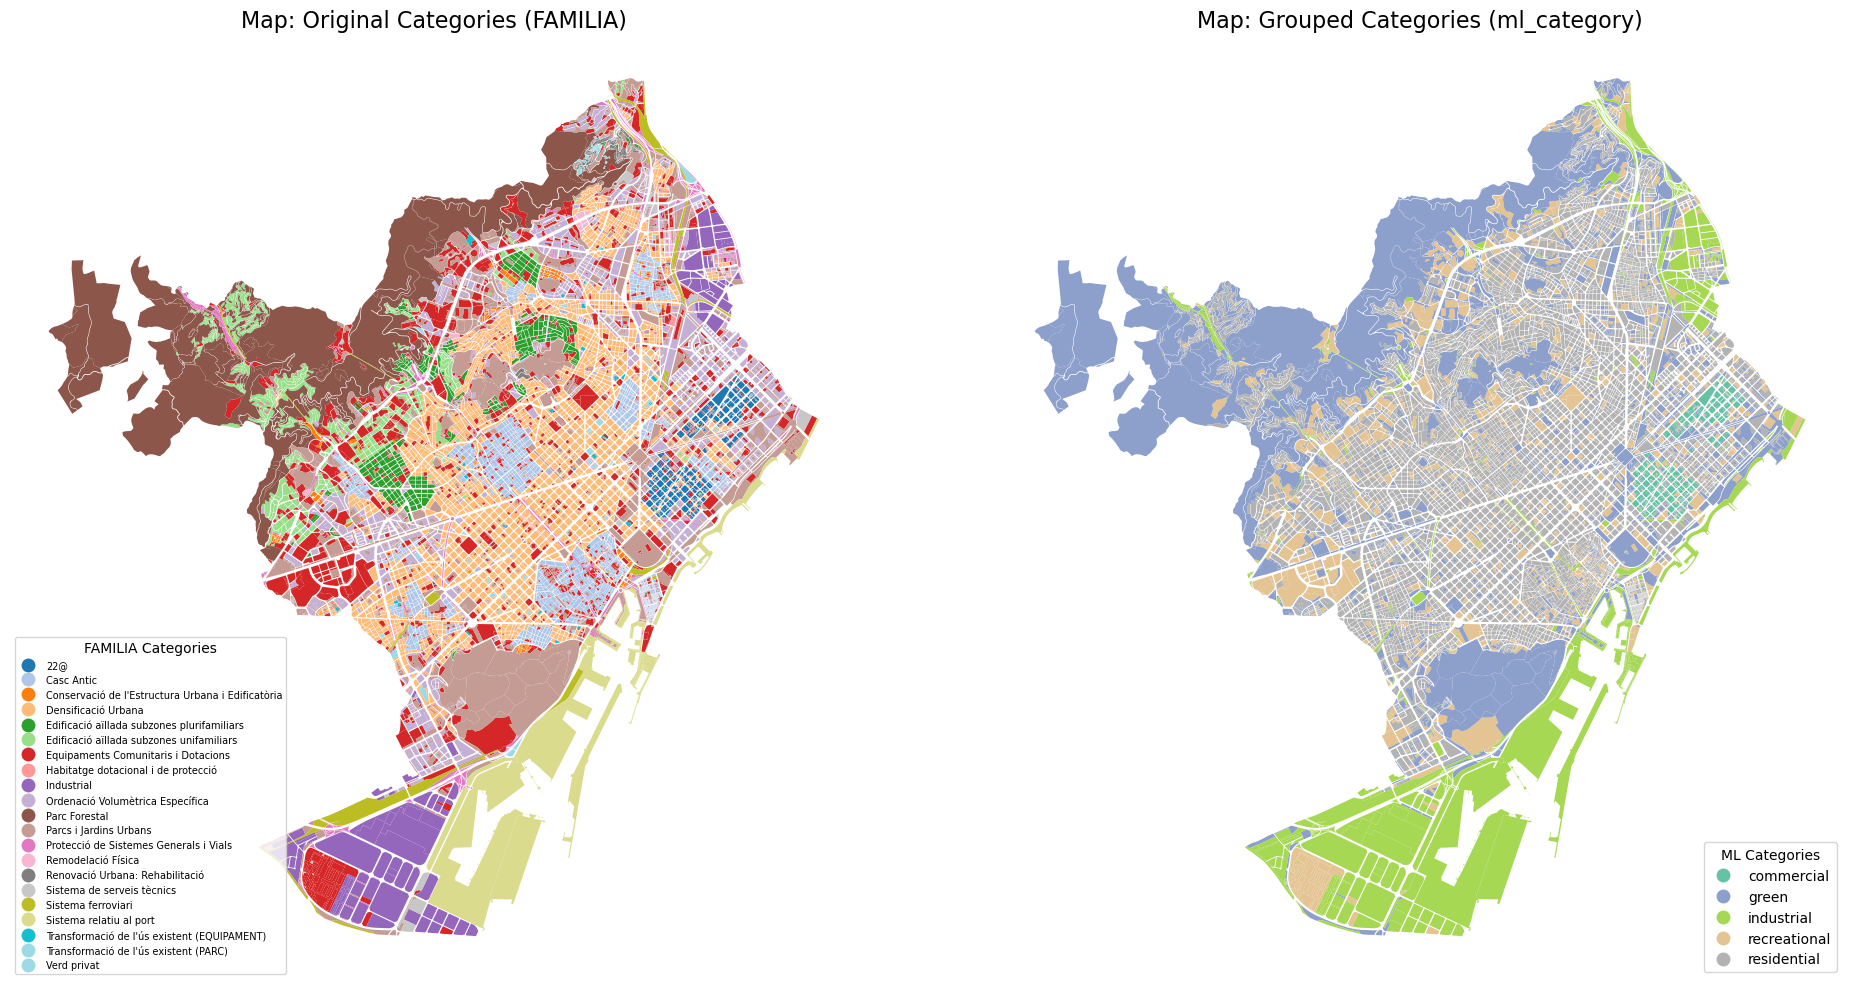

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Plot Before Grouping Map
landuse.plot(
    column='FAMILIA', 
    ax=axes[0], 
    cmap='tab20', 
    legend=True,
    legend_kwds={'loc': 'lower left', 'title': "FAMILIA Categories", 'fontsize': 7}
)
axes[0].set_title("Map: Original Categories (FAMILIA)", fontsize=16)
axes[0].set_axis_off()

# Plot After Grouping Map
landuse.plot(
    column='ml_category', 
    ax=axes[1], 
    cmap='Set2', 
    legend=True, 
    legend_kwds={'loc': 'lower right', 'title': "ML Categories"}
)
axes[1].set_title("Map: Grouped Categories (ml_category)", fontsize=16)
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

## Define the Spatial Math Function
This function takes the street geometries, draws the buffer, intersects it with the official land use polygons, and pivots the calculated areas into percentage columns.

In [ ]:
def calculate_landuse_pct(streets_gdf, landuse_gdf, buffer_size):
    print(f"Processing {buffer_size}m buffers...")
    
    # Create buffers and calculate total buffer area
    buffered = streets_gdf.copy()
    buffered['geometry'] = buffered.geometry.buffer(buffer_size)
    buffered['buffer_area'] = buffered.geometry.area
    
    # Intersect with landuse
    intersection = gpd.overlay(buffered, landuse_gdf, how='intersection')
    intersection['intersected_area'] = intersection.geometry.area
    
    # Group by street and category to get total area per category
    # NOTE: Group by both fid and TRAM to guarantee row preservation mapping
    grouped = intersection.groupby(['fid', 'TRAM', 'ml_category'])['intersected_area'].sum().reset_index()
    
    # Merge back to get the total buffer area and calculate percentage
    grouped = grouped.merge(buffered[['fid', 'TRAM', 'buffer_area']], on=['fid', 'TRAM'])
    grouped['pct'] = (grouped['intersected_area'] / grouped['buffer_area']) * 100
    
    # Pivot to wide format (Machine Learning ready)
    features = grouped.pivot(index=['fid', 'TRAM'], columns='ml_category', values='pct').fillna(0)
    
    # Rename columns to include the buffer size
    features.columns = [f"{col}_pct_{buffer_size}m" for col in features.columns]
    
    return features.reset_index()

## Execute Buffer Calculations
Running the function for both 50m and 100m. This might take a minute or two depending on the density of the polygons.

In [7]:
features_50m = calculate_landuse_pct(noise_streets, landuse, 50)
features_100m = calculate_landuse_pct(noise_streets, landuse, 100)

display(features_50m.head(3))

Processing 50m buffers...
Processing 100m buffers...


,TRAM,commercial_pct_50m,green_pct_50m,industrial_pct_50m,recreational_pct_50m,residential_pct_50m
0,LRD0001,0.0,5.023397,18.526316,7.315722,2.592209
1,LRD0002,0.0,5.095533,20.054553,0.000000,9.871660
2,LRD0003,0.0,15.840463,0.000000,21.698592,2.127330


## Merge
Attach our new percentage features back to the original tabular street data.

In [ ]:
# Create a baseline dataframe without the geometry
final_df = pd.DataFrame(noise_streets.drop(columns=['geometry']))

# Attach the 50m and 100m features
final_df = final_df.merge(features_50m, on=['fid', 'TRAM'], how='left')
final_df = final_df.merge(features_100m, on=['fid', 'TRAM'], how='left')

# Fill any remaining NaNs with 0 
final_df = final_df.fillna(0)

In [ ]:
# Create a final clean dataset with our core target variables and the new land use percentages
dataset = pd.DataFrame({
    "fid": final_df['fid'],
    "street_id": final_df['TRAM'],
    "noise_day": final_df['TOTAL_D'],
    "noise_evening": final_df['TOTAL_E'],
    "noise_night": final_df['TOTAL_N'],
})

# Extract all percentage columns we just created (e.g. residential_pct_50m, etc.)
pct_columns = [col for col in final_df.columns if '_pct_' in col]

# Add them to our new dataset
for col in pct_columns:
    dataset[col] = final_df[col]

# Fill any NaN values with 0
dataset = dataset.fillna(0)

display(dataset.head(10))

# Export to CSV
import os
output_dir = "../../data/processed"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "landuse_features.csv"), index=False)
print("Exported landuse_features.csv")

,street_id,noise_day,noise_evening,noise_night,commercial_pct_50m,green_pct_50m,industrial_pct_50m,recreational_pct_50m,residential_pct_50m,commercial_pct_100m,green_pct_100m,industrial_pct_100m,recreational_pct_100m,residential_pct_100m
0,T04719W,70 - 75 dB(A),65 - 70 dB(A),60 - 65 dB(A),0.0,0.000000,0.000000,24.722236,36.130137,0.0,2.215418,0.184230,24.465892,41.263371
1,T19941Z,45 - 50 dB(A),45 - 50 dB(A),< 40 dB(A),0.0,30.721299,0.000000,13.091872,38.204944,0.0,17.103831,0.000000,14.549478,39.350735
2,T18111R,55 - 60 dB(A),55 - 60 dB(A),50 - 55 dB(A),0.0,17.325855,0.000000,5.252444,46.989259,0.0,19.671078,0.162294,22.254779,37.257617
3,T03222Y,60 - 65 dB(A),55 - 60 dB(A),60 - 65 dB(A),0.0,13.772162,0.000000,0.000000,55.923140,0.0,25.261810,0.000000,0.000000,44.508484
4,T17625I,55 - 60 dB(A),55 - 60 dB(A),50 - 55 dB(A),0.0,0.000000,0.000000,0.000000,38.761534,0.0,0.376939,0.000000,0.000000,50.404589
5,T05360P,55 - 60 dB(A),55 - 60 dB(A),50 - 55 dB(A),0.0,0.000000,4.299892,17.120455,59.381205,0.0,0.000000,3.053041,21.691459,55.214777
6,T08863T,50 - 55 dB(A),50 - 55 dB(A),45 - 50 dB(A),0.0,0.000000,0.000000,0.000000,60.249555,0.0,2.966376,0.872712,2.157992,62.134468
7,T00236S,45 - 50 dB(A),45 - 50 dB(A),40 - 45 dB(A),0.0,6.332248,0.567756,8.379010,44.003367,0.0,14.859117,6.228124,7.812867,33.847860
8,T13009A,55 - 60 dB(A),55 - 60 dB(A),50 - 55 dB(A),0.0,0.027655,0.000000,0.000000,88.324142,0.0,7.262873,0.063755,0.920332,78.339899
9,T11921P,60 - 65 dB(A),55 - 60 dB(A),50 - 55 dB(A),0.0,17.634777,0.000000,0.000000,50.935351,0.0,9.513814,0.000000,5.822407,57.494331


## Data Visualization
Let's visualize the calculated land use parameters geographically on the street network using `geopandas.plot()` to verify the results.

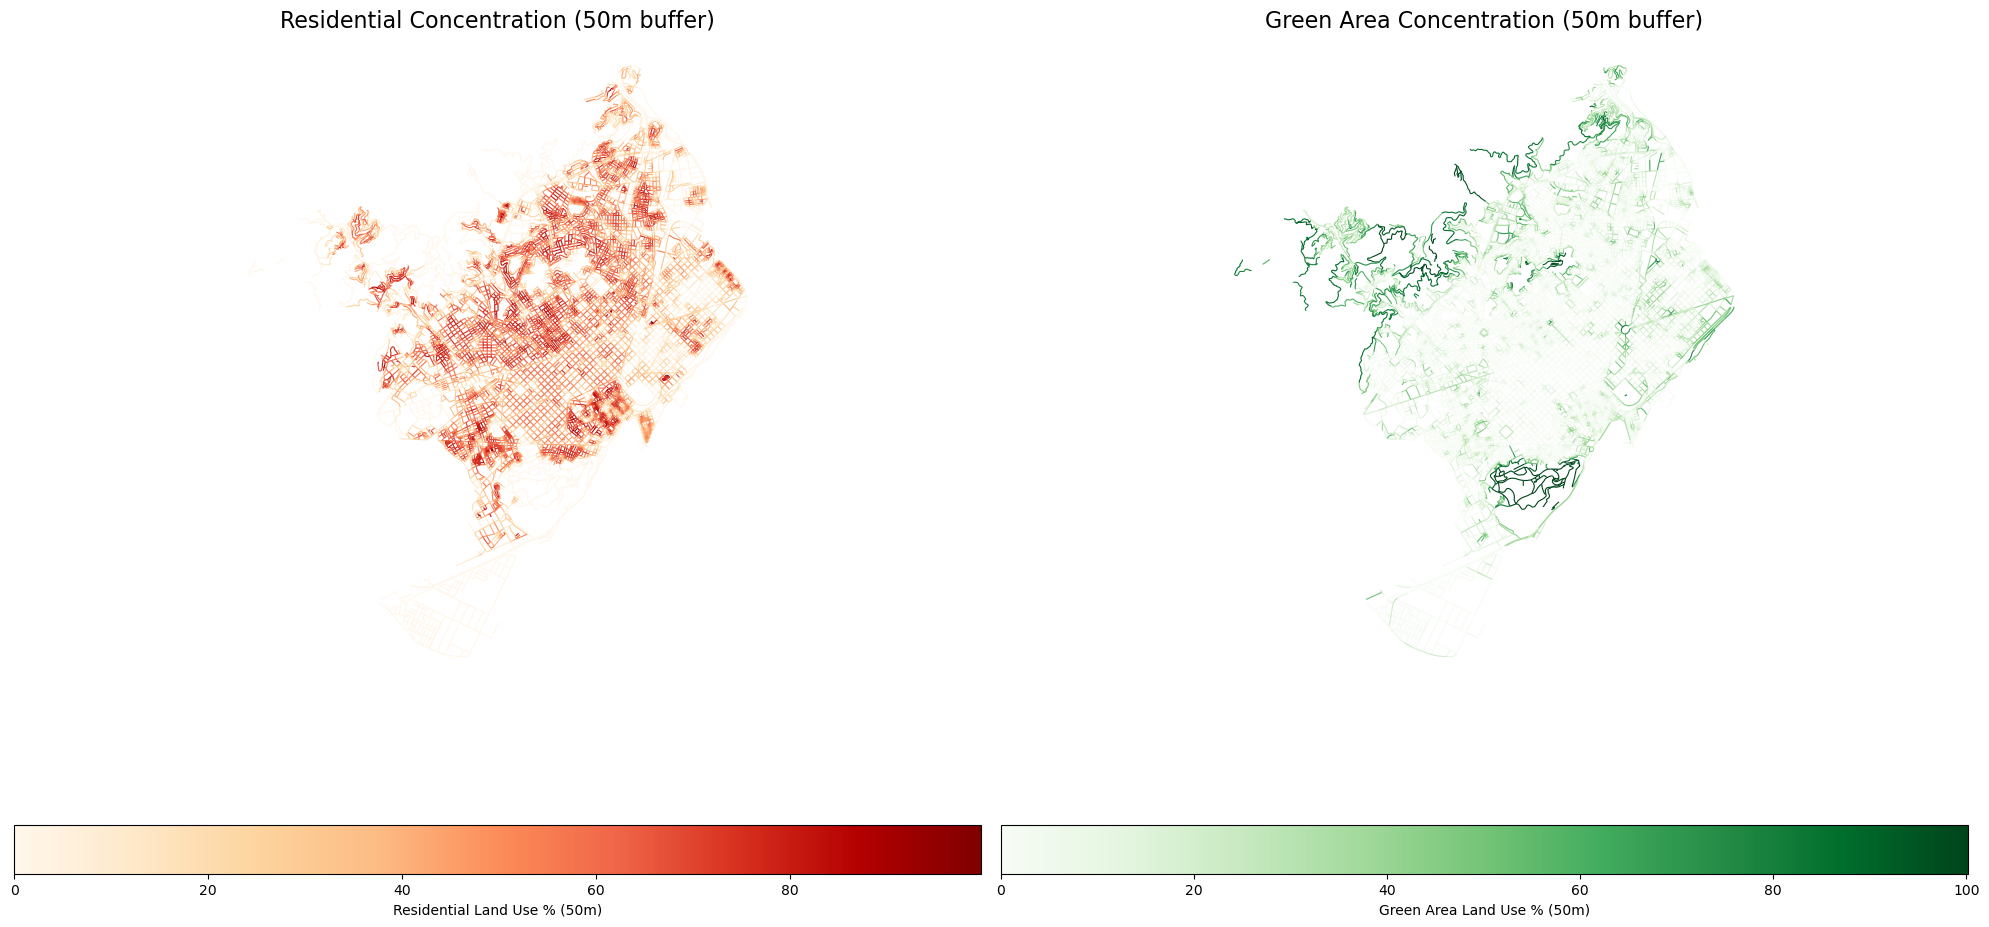

In [10]:
import matplotlib.pyplot as plt

# Re-attach the percentage features to our GeoDataFrame for mapping
gdf_mapped = noise_streets.merge(dataset.drop(columns=['noise_day', 'noise_evening', 'noise_night']), left_on='TRAM', right_on='street_id')

# Create a figure with subplots to show different land use percentages
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Plot Residential 50m
gdf_mapped.plot(
    column='residential_pct_50m', 
    ax=axes[0],
    cmap='OrRd', 
    legend=True,
    legend_kwds={'label': "Residential Land Use % (50m)", 'orientation': "horizontal"},
    linewidth=0.8
)
axes[0].set_title("Residential Concentration (50m buffer)", fontsize=16)
axes[0].set_axis_off()

# Plot Green 50m
gdf_mapped.plot(
    column='green_pct_50m', 
    ax=axes[1],
    cmap='Greens', 
    legend=True,
    legend_kwds={'label': "Green Area Land Use % (50m)", 'orientation': "horizontal"},
    linewidth=0.8
)
axes[1].set_title("Green Area Concentration (50m buffer)", fontsize=16)
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

# Data export for csv

In [11]:
import os
output_dir = "../../data/processed"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "landuse_features.csv"), index=False)
print("Exported landuse_features.csv")

Exported landuse_features.csv
